# Sequential Analysis using BioPython

Course Outline:
 - BioPython library preparation
 - Working with sequence
 - Sequence and Subquence Manipulation
 - Nucleotide FrequencyPlot

In [2]:
# Course Outline:
#  - BioPython library preparation
#  - Working with sequence
#  - Sequence and Subquence Manipulation
#  - Nucleotide FrequencyPlot

**BioPython preparation**

BioPython = Library untuk mengolah data biologi

In [3]:
%pip install BioPython
import Bio

Note: you may need to restart the kernel to use updated packages.


**Working with sequence**

In [4]:
from Bio.Seq import Seq

# Making Sequence
seqA = Seq('CGATCGATCGAT')
print(seqA)

CGATCGATCGAT


**Sequence and Subquence Manipulation**

In [5]:
# Add other sequence
seqB = Seq("ACGTACGTACGT")
total = seqA + seqB
print(total)

CGATCGATCGATACGTACGTACGT


In [6]:
# Doing Slicing
slicing = seqA[0:4:2]
print(slicing)

CA


In [7]:
# Doing count
countA = seqA.count('A')
print(countA)

3


In [8]:
# Doing find
findA = seqA.find('A')
print(findA)

# Doing index
indexA = seqA.index('A')
print(indexA)

2
2


In [9]:
# nt search --> Mencari subsequebce dari dalam sequence itu sendiri
from Bio.SeqUtils import nt_search

mainSeq = Seq('ACGTACGTACGT')
subSeq = Seq('GT')
search_the_subsequence = nt_search(str(mainSeq),str(subSeq))
print(search_the_subsequence)
# ['GT', 2, 6, 10]
# 2 --> Mulai dari index ke-2
# 6 --> Bisa juga  mulai dari index ke-6
# 10 --> Bisa juga  mulai dari index ke-10

['GT', 2, 6, 10]


**Nucleotide Frequency Plot**

In [10]:
from matplotlib import pyplot as plt
from collections import Counter

Counter({'C': 4, 'G': 4, 'A': 2, 'T': 2})


<BarContainer object of 4 artists>

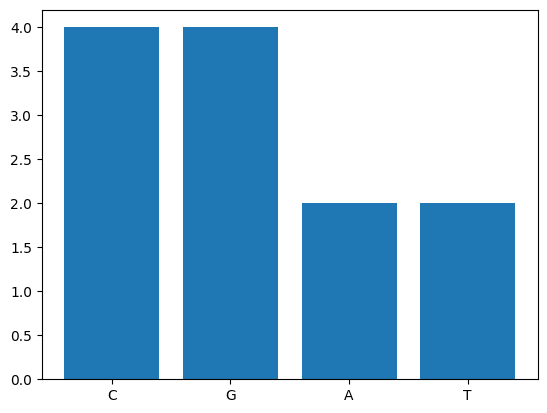

In [11]:
seqA = ('CGATCGATCGCG')
dna_freq = Counter(seqA)
print(dna_freq)

# We will start ploting
plt.bar(dna_freq.keys(),dna_freq.values())

In [12]:
print(dna_freq.keys())
print(dna_freq.values())

dict_keys(['C', 'G', 'A', 'T'])
dict_values([4, 4, 2, 2])


In [13]:
aa = "abcd"
print(aa[:-1])


abc


# DNA Composition Analysis

Course Structure
- GC and AT Composition on DNA
- Melting Point of DNA
- Moleular Weight

In [14]:
import Bio
from Bio.Seq import Seq


# Make the sequence
DNA = Seq('ATGGACGCGTGCGAT')
print(DNA)

print(DNA.count("A")) # Complement

ATGGACGCGTGCGAT
3


**GC and AT Composition on DNA**

In [15]:
# Counting the GC and AT percentages in a DNA
# GC percentage --> Mempengaruhi melting temperature sebuah DNA
# Ada 2 cara untuk menghitung persen GC dan AT
# 1. Bulit-in function
# 2. Cara manual

# Built-in function
from Bio.SeqUtils import gc_fraction
persentase_gc = gc_fraction(DNA)
print(persentase_gc)
print(persentase_gc*100)

persentase_at = 1 - persentase_gc
print(persentase_at*100)


0.6
60.0
40.0


In [16]:
# Manual calculation

# user-defined function
def GC_counter(seq):
    gc = []
    for x in seq:
        if x == 'G' or x == 'C':
            gc.append(x)
    print(gc)
    return len(gc)/len(seq)

print(f"GC content (manual): {GC_counter(DNA)*100:.2f}%")
print(f"AT content (manual): {100 - GC_counter(DNA)*100:.2f}%")


['G', 'G', 'C', 'G', 'C', 'G', 'G', 'C', 'G']
GC content (manual): 60.00%
['G', 'G', 'C', 'G', 'C', 'G', 'G', 'C', 'G']
AT content (manual): 40.00%


In [17]:
# list comprehension
def GC_counter2(seq):
    gc = [x for x in seq if x == 'G' or x == 'C']
    print(gc)
    return len(gc)/len(seq)

print(f"GC content (manual): {GC_counter2(DNA)*100:.2f}%")

def AT_counter(seq):
    at = [x for x in seq if x in 'AT']
    print(at)
    return len(at)/len(seq)

print(f"AT content (manual): {AT_counter2(DNA)*100:.2f}%")

['G', 'G', 'C', 'G', 'C', 'G', 'G', 'C', 'G']
GC content (manual): 60.00%


NameError: name 'AT_counter2' is not defined

['G', 'G', 'C', 'G', 'C', 'G', 'G', 'C', 'G']
['A', 'T', 'A', 'T', 'A', 'T']


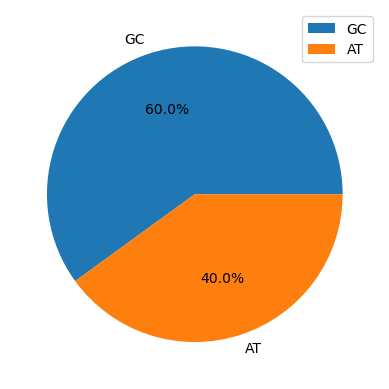

In [ ]:
# Make a plot to visualize the GC and AT persent
plt.pie([GC_counter(DNA), AT_counter(DNA)], labels=['GC', 'AT'], autopct='%1.1f%%')
plt.legend(["GC", "AT"])
plt.show()

**Melting Point of DNA**

Melting point of DNA = Temperature at which dua untai DNA terputus

In [ ]:
# Ada beberapa cara untuk hitung melting point
#  1. user-defined function
#  2. built-in function


In [ ]:
# Secar bulit in function
from Bio.SeqUtils import MeltingTemp as mt
print(mt.Tm_GC(DNA)) # Menghitung melting point berdasarkan GC content
print(mt.Tm_NN(DNA)) # Menghitung melting point berdasarkan nearest-neighbor parameters
print(mt.Tm_Wallace(DNA)) # Menghitung melting point berdasarkan Wallace rule


44.5029020719779
50.346125847238625
48.0


Walace rule

<img src="walace_rule.png" width="600">

In [ ]:
# Calculate the melting point with the walace rule
def Wallace_Buatan(seq):
    jumlahA = seq.count('A')
    jumlahT = seq.count('T')
    jumlahG = seq.count('G')
    jumlahC = seq.count('C')
    # len(seq) == jumlahA + jumlahT + jumlahG + jumlahC
    if len(seq) < 14:
        Tm = 2*(jumlahA + jumlahT) + 4*(jumlahG + jumlahC)
    elif len(seq) >= 14:
        Tm = round(64.9 + 41*(jumlahG + jumlahC - 16.4)/len(seq), 2)
    return Tm

print(mt.Tm_GC(DNA)) 
print(mt.Tm_NN(DNA)) 
print(mt.Tm_Wallace(DNA)) 
print(f"Melting point (manual): {Wallace_Buatan(DNA)}")



44.5029020719779
50.346125847238625
48.0
Melting point (manual): 44.67


**Molecular Weight**

Molecular weight (berat molekul) adalah jumlah massa dari semua atom yang menyusun sebuah molekul.


Satuan yang sering digunakan adalah:
- Dalton (Da) atau
- gram/mol (g/mol)

Contoh sederhana:

Air memiliki rumus:

H₂O

Atom-atomnya:

H ≈ 1 Da

H ≈ 1 Da

O ≈ 16 Da


Sehingga:


1 + 1 + 16 = 18 Da


Jadi molecular weight air sekitar 18 Da.


In [ ]:
# We will calculate:
#  - Molecular weight of a DNA
#  - Molecular weight of a nucleotide
# NOTE:
# jika sequence = ATGGACGCGTGCGAT
# maka nukeotida adalah A, T, G, C, G, A, C, G, T, G, C, G, A, T

4712.995199999999


In [ ]:
# Molecular weight of a DNA
from Bio.SeqUtils import molecular_weight
print(molecular_weight(DNA, seq_type='DNA')) # Molecular weight of a DNA

4712.995199999999


In [ ]:
# Molecular weight of a nucleotide
def nucleotide_molecular_weight(seq, nucleotide):
    n = [x for x in seq if x == nucleotide]
    n_string = ''.join(n)
    print(n)
    return molecular_weight(n_string, seq_type='DNA')

print(nucleotide_molecular_weight(DNA, 'G')) # Molecular weight of a nucleotide G
print(nucleotide_molecular_weight(DNA, 'A')) # Molecular weight of a nucleotide A

['G', 'G', 'G', 'G', 'G', 'G']
1993.2507000000003
['A', 'A', 'A']
957.6347999999998


# Protein Synthesis

Course structure
 - Protein Synthesis
 - Amino Acid Codon Table
 - 3D Structure of Protein(with the py3Dmol)

**Protein Synthesis**

Protein synthesis adalah proses sel membuat protein berdasarkan informasi yang tersimpan di DNA.

Protein sangat penting karena digunakan untuk:
- membangun sel dan jaringan
- memperbaiki sel yang rusak
- membuat enzim
- membuat hormon tertentu
- membantu berbagai fungsi tubuh.

Gambaran sederhananya

Bayangkan sebuah pabrik.
- DNA = buku resep.
- Gen = satu resep di dalam buku.
- mRNA = fotokopi resep yang dibawa ke dapur.
- Ribosom = koki.
- Asam amino = bahan-bahan makanan.
- Protein = hidangan yang selesai dibuat.

Jadi, sel tidak membawa buku resep (DNA) ke dapur. Sebagai gantinya, sel membuat salinan resep (mRNA), lalu ribosom menggunakan salinan tersebut untuk membuat protein.

Gambaran sederhana Protein synthesis

                         DNA

                          │

                          │  (Transcription)

                          ▼

                         mRNA

                          │

                          │  (Translation)

                          ▼

                        Protein


If we zoom in

<img src="protein.png" width="600">

The explanation of the picture + analogi koki

| Analogi Pabrik                    | Gambar                                                                              | Penjelasan                                                                      |
| --------------------------------- | ----------------------------------------------------------------------------------- | ------------------------------------------------------------------------------- |
| 📖 **DNA = buku resep**           | DNA di bagian paling atas                                                           | DNA menyimpan semua instruksi untuk membuat protein.                            |
| 📄 **Gen = satu resep**           | Bagian DNA yang dibuka                                                              | Tidak seluruh DNA digunakan. Hanya **satu gen** (satu bagian DNA) yang disalin. |
| 📋 **mRNA = fotokopi resep**      | RNA yang terbentuk pada tahap **Transcription**                                     | Sel membuat salinan informasi dari gen agar tidak perlu membawa DNA asli.       |
| 👨‍🍳 **Ribosom = koki**          | (Tidak digambar secara eksplisit) Pada tahap **Translation**, ribosom membaca mRNA. | Ribosom "membaca resep" pada mRNA.                                              |
| 🥩 **Asam amino = bahan makanan** | Met, Ile, Ser                                                                       | Ribosom mengambil asam amino sesuai instruksi pada mRNA. Asam amino digunakan untuk membentuk protein                  |
| 🍽️ **Protein = hidangan jadi**   | Polypeptide                                                                         | Rangkaian asam amino menjadi protein.                                           |


Buku resep (DNA)

        │
        │ Salin resep
        ▼

Fotokopi resep (mRNA)

        │
        │ Dibaca oleh koki
        ▼

Koki memasak (ribosom)

        │
        |
        ▼
Kue jadi (protein)  
        

**Complement DNA/cDNA:**

DNA is double-stranded, meaning it consists of two strands joined together to form a double helix. The two strands are called complementary because each base on one strand always pairs with a specific base on the other strand.

Pairing rules:

| DNA Base     | Pairs With   |
| ------------ | ------------ |
| A (Adenine)  | T (Thymine)  |
| T (Thymine)  | A (Adenine)  |
| G (Guanine)  | C (Cytosine) |
| C (Cytosine) | G (Guanine)  |

Example of DNA:
```
ATGATCTCGTAA   (Strand 1)
||||||||||||
TACTAGAGCATT   (Strand 2)
```

Explanation
- Top strand = one DNA strand.
- Bottom strand = complementary DNA strand.
- Together they form DNA 

In [ ]:
# Make a Sequence(One strand of the DNA)
dnaSeq = Seq('ATGATCTCGTAA')
# Determine the complementary strand of the DNA
complementaryStrand = dnaSeq.complement()

print(f"One Strand of DNA(sense): {dnaSeq}")
print(f"Second Strand of DNA(Complementary or antisense): {complementaryStrand}")

One Strand of DNA(sense): ATGATCTCGTAA
Second Strand of DNA(Complementary or antisense): TACTAGAGCATT


: 

**Transcription and Translation**
- Transcription --> proses menyalin informasi dari DNA menjadi mRNA.
- Translation --> proses menerjemahkan urutan mRNA menjadi urutan asam amino sehingga terbentuk protein.

In [ ]:
# Transcribe the DNA sequence to RNA
rnaSeq = dnaSeq.transcribe()
print(f"RNA Sequence: {rnaSeq}") # So basically is the first strand of the DNA is transcribed to RNA(where T becomes U)

RNA Sequence: AUGAUCUCGUAA


In [ ]:
# Translate the RNA sequence to a protein
aminoAcid= rnaSeq.translate()
print(f"Amino acid: {aminoAcid}")

# We will now determine the polypeptide based on the amino acid sequence
from Bio.SeqUtils import seq1, seq3
polypeptide = seq3(aminoAcid) # seq3() function will convert the amino acid sequence to a polypeptide sequence
print(f"Polypeptide: {polypeptide}")
back_to_aminoAcid = seq1(polypeptide) # seq1() function will convert the polypeptide sequence back to amino acid sequence
print(f"Back to Amino acid: {back_to_aminoAcid}")

Amino acid: MIS*
Polypeptide: MetIleSerTer
Back to Amino acid: MIS*


**Amino Acid Codon Table**

Remember the protein sythesis above:

```
DNA
 │
 │ Transcription
 ▼
mRNA
 │
 │ Translation
 ▼
Protein

```

During translation, the ribosome has to answer this question:

*This codon (3 RNA letters) corresponds to which amino acid?*

To answer that question, the ribosome uses the genetic code, which is summarized in the Amino Acid Codon Table.

Ada 2 jenis tabble nya:
  - Pakai standard DNA(jadi pakai T)
  - Pakai standard sesudah di translasi(jadi T diganti U)

In [ ]:
# Let's look what the tabble look like 
from Bio.Data import CodonTable

# The DNA standard
table = CodonTable.unambiguous_dna_by_name["Standard"] 
print(table)

Table 1 Standard, SGC0

  |  T      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
T | TTT F   | TCT S   | TAT Y   | TGT C   | T
T | TTC F   | TCC S   | TAC Y   | TGC C   | C
T | TTA L   | TCA S   | TAA Stop| TGA Stop| A
T | TTG L(s)| TCG S   | TAG Stop| TGG W   | G
--+---------+---------+---------+---------+--
C | CTT L   | CCT P   | CAT H   | CGT R   | T
C | CTC L   | CCC P   | CAC H   | CGC R   | C
C | CTA L   | CCA P   | CAA Q   | CGA R   | A
C | CTG L(s)| CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | ATT I   | ACT T   | AAT N   | AGT S   | T
A | ATC I   | ACC T   | AAC N   | AGC S   | C
A | ATA I   | ACA T   | AAA K   | AGA R   | A
A | ATG M(s)| ACG T   | AAG K   | AGG R   | G
--+---------+---------+---------+---------+--
G | GTT V   | GCT A   | GAT D   | GGT G   | T
G | GTC V   | GCC A   | GAC D   | GGC G   | C
G | GTA V   | GCA A   | GAA E   | GGA G   | A
G | GTG V   | GCG A   | GAG E   | GGG G   | G
--+---------

In [ ]:
# The "After translation" standard
table = CodonTable.unambiguous_rna_by_name["Standard"] 
print(table)

Table 1 Standard, SGC0

  |  U      |  C      |  A      |  G      |
--+---------+---------+---------+---------+--
U | UUU F   | UCU S   | UAU Y   | UGU C   | U
U | UUC F   | UCC S   | UAC Y   | UGC C   | C
U | UUA L   | UCA S   | UAA Stop| UGA Stop| A
U | UUG L(s)| UCG S   | UAG Stop| UGG W   | G
--+---------+---------+---------+---------+--
C | CUU L   | CCU P   | CAU H   | CGU R   | U
C | CUC L   | CCC P   | CAC H   | CGC R   | C
C | CUA L   | CCA P   | CAA Q   | CGA R   | A
C | CUG L(s)| CCG P   | CAG Q   | CGG R   | G
--+---------+---------+---------+---------+--
A | AUU I   | ACU T   | AAU N   | AGU S   | U
A | AUC I   | ACC T   | AAC N   | AGC S   | C
A | AUA I   | ACA T   | AAA K   | AGA R   | A
A | AUG M(s)| ACG T   | AAG K   | AGG R   | G
--+---------+---------+---------+---------+--
G | GUU V   | GCU A   | GAU D   | GGU G   | U
G | GUC V   | GCC A   | GAC D   | GGC G   | C
G | GUA V   | GCA A   | GAA E   | GGA G   | A
G | GUG V   | GCG A   | GAG E   | GGG G   | G
--+---------

So after the translation(lihat proses di atas), maka jadi AUGAUCUCGUAA

AUG = Ms

AUC = I

UCG = S

UCG = S

UAA = *

makanya tadi Amino acid: MIS*

**Protein Data Bank(PDB)**

So if Protein synthesis explains how a protein is made. Protein Data Bank(PDB)
It is a database that stores the detailed 3D information about what the finished protein looks like.

In [ ]:
# let see what the database look like
%pip install py3Dmol
import py3Dmol
view = py3Dmol.view(query='pdb:1BNA') # 1BNA is the PDB ID of the DNA structure
                                      # So we are loading the 3D structure of the DNA from the PDB database
                                      # that has in ID 1BNA
view.setStyle({'cartoon': {'color': 'spectrum'}}) # set the style of the 3D structure to cartoon and color it with spectrum
view.show() # Let see

Note: you may need to restart the kernel to use updated packages.


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Sequence Alingment Using Biopython

Course structure
 - Local and Global Alingment
 - Similairity Analysis
 - Hamming Distance
 - Leveinshten Distance
 - Dot Plot